# 04 — Edge Efficiency: Distillation, Quantization, and the Quality/Cost Pareto

This is the headline differentiator for edge/semiconductor-facing roles: rather than
stopping at accuracy, we characterize the **cost** of the model along the axes that
matter for on-device deployment -- checkpoint size, latency, throughput, peak VRAM --
and show how much can be recovered with knowledge distillation and quantization.

Pipeline (produced by background scripts, loaded here for analysis):
- `scripts/distill.py --mode distill` : distills the trained vanilla LM into a small (3-layer) student.
- `scripts/distill.py --mode scratch` : trains an identically-sized student from scratch (the honest baseline).
- `scripts/benchmark.py` : measures perplexity / size / latency / throughput / VRAM for FP32, FP16 (GPU), INT8 (CPU, dynamic quantization), and both students -> `outputs/logs/efficiency_pareto.csv`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import LOGS_DIR, get_device
from src import plots

plots.setup_style()
device = get_device()
print('Device:', device)

Device: cuda


## 4.1 Distillation vs from-scratch student

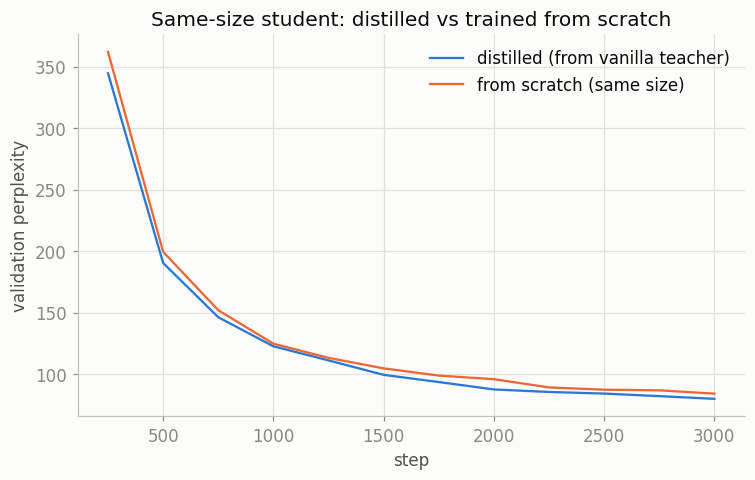

Best distilled val_ppl: 79.772
Best scratch   val_ppl: 84.021


In [2]:
distilled_log = pd.read_csv(LOGS_DIR / 'student_distilled_metrics.csv')
scratch_log = pd.read_csv(LOGS_DIR / 'student_scratch_metrics.csv')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(distilled_log['step'], distilled_log['val_ppl'], color=plots.CATEGORICAL[0], label='distilled (from vanilla teacher)')
ax.plot(scratch_log['step'], scratch_log['val_ppl'], color=plots.CATEGORICAL[5], label='from scratch (same size)')
ax.set_xlabel('step'); ax.set_ylabel('validation perplexity')
ax.set_title('Same-size student: distilled vs trained from scratch')
ax.legend(frameon=False)
fig.tight_layout()
plots.savefig(fig, '04_distill_vs_scratch')
plt.show()

print(f'Best distilled val_ppl: {distilled_log["val_ppl"].min():.3f}')
print(f'Best scratch   val_ppl: {scratch_log["val_ppl"].min():.3f}')

## 4.2 Quality-vs-cost Pareto frontier

In [3]:
pareto_df = pd.read_csv(LOGS_DIR / 'efficiency_pareto.csv')
pareto_df

,variant,device,val_ppl,size_mb,latency_per_token_ms,throughput_tok_s,peak_vram_mb
0,teacher_fp32,cuda,29.301,116.18,4.438,225.346,119.498
1,teacher_fp16,cuda,29.303,58.09,3.771,265.189,173.639
2,teacher_int8_cpu,cpu,28.327,36.91,6.230,160.507,NaN
3,student_distilled,cuda,82.804,19.04,1.860,537.738,202.690
4,student_scratch,cuda,86.474,19.04,1.848,541.025,202.690


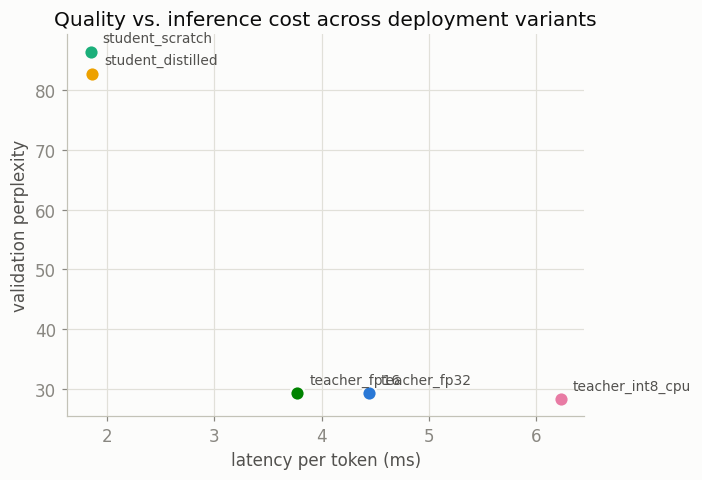

In [4]:
fig, ax = plots.plot_pareto(
    pareto_df['latency_per_token_ms'], pareto_df['val_ppl'], pareto_df['variant'],
    xlabel='latency per token (ms)', ylabel='validation perplexity',
    title='Quality vs. inference cost across deployment variants',
)
plots.savefig(fig, '04_pareto_ppl_vs_latency')
plt.show()

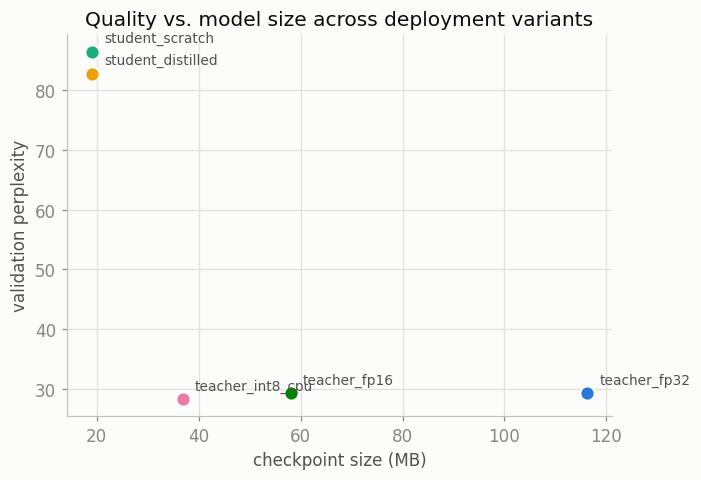

In [5]:
fig, ax = plots.plot_pareto(
    pareto_df['size_mb'], pareto_df['val_ppl'], pareto_df['variant'],
    xlabel='checkpoint size (MB)', ylabel='validation perplexity',
    title='Quality vs. model size across deployment variants',
)
plots.savefig(fig, '04_pareto_ppl_vs_size')
plt.show()

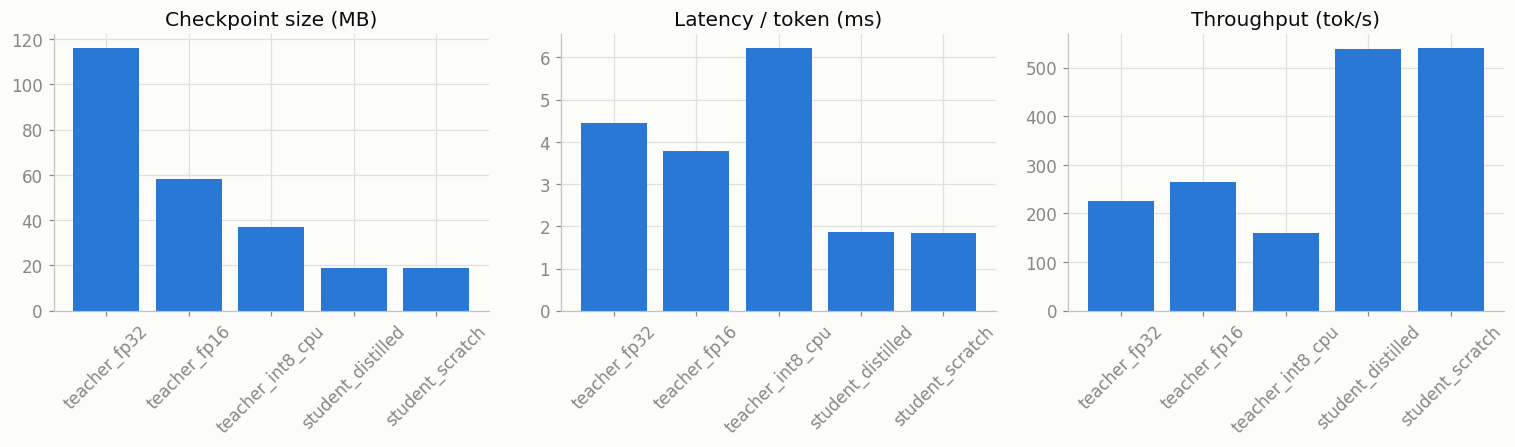

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, title in zip(axes, ['size_mb', 'latency_per_token_ms', 'throughput_tok_s'],
                          ['Checkpoint size (MB)', 'Latency / token (ms)', 'Throughput (tok/s)']):
    ax.bar(pareto_df['variant'], pareto_df[col], color=plots.CATEGORICAL[0])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plots.savefig(fig, '04_variant_bars')
plt.show()

## Summary

In [7]:
print('Task 2/3 edge-efficiency deliverables:')
print(pareto_df.to_string(index=False))
print(f'\nFigures: {plots.FIG_DIR}')

Task 2/3 edge-efficiency deliverables:
          variant device  val_ppl  size_mb  latency_per_token_ms  throughput_tok_s  peak_vram_mb
     teacher_fp32   cuda   29.301   116.18                 4.438           225.346       119.498
     teacher_fp16   cuda   29.303    58.09                 3.771           265.189       173.639
 teacher_int8_cpu    cpu   28.327    36.91                 6.230           160.507           NaN
student_distilled   cuda   82.804    19.04                 1.860           537.738       202.690
  student_scratch   cuda   86.474    19.04                 1.848           541.025       202.690

Figures: F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\figures
